# 01 - Preprocessing: raw EEG + fMRI -> training pairs

**Run this notebook on the PC that has the raw data (`E:\EEG_to_FMRI`). No GPU needed.**

It is step 1 of 2:

| notebook | runs on | does |
|---|---|---|
| **`01_Preprocess_EEG_fMRI_to_h5.ipynb`** (this one) | the data PC, CPU only | raw scanner files -> clean training pairs in `.h5` files |
| `02_Train_Spec2VolCAMU_Net.ipynb` | the GPU PC | builds the model, trains it, evaluates it |

We are re-implementing the paper **Spec2VolCAMU-Net** (He et al., 2025, arXiv:2505.09521) and its
code (`github.com/hdy6438/Spec2VolCAMU-Net`) inside notebooks, so nothing needs to be cloned or
installed from the repo.

---

## What we are doing, in plain words

A person lay in an MRI scanner wearing an EEG cap. Two machines recorded the same brain at the
same time:

- the **EEG cap** wrote down tiny voltages on the scalp, 250 times a second
- the **MRI scanner** took a 3D picture of blood-oxygen levels, once every 2.16 seconds

We want a model that looks at the EEG and **draws the MRI picture**.

A neural network cannot learn from two raw files that have different speeds and different units.
So this notebook turns them into matched question-and-answer cards:

```
   QUESTION (model input)                         ANSWER (model output)
   the last 43 seconds of EEG,            ->      the 3D brain picture that was
   as 20 small "frequency pictures"               taken right after those 43 seconds
```

Each subject gives 274 such cards. 16 subjects give 4,384.

```
 RAW EEG  (64 wires x ~170,000 voltage samples)        RAW fMRI  (64 x 64 x 30 voxels x 300 pictures)
      |                                                      |
      | cut into 2.16 s pieces, one per MRI picture          | throw away the first 6 pictures
      | turn each piece into "how much of each frequency"    | (scanner still warming up)
      | drop the first 6 pieces too                          |
      v                                                      v
 294 frequency pictures, each 64 x 249                  294 brain pictures, each 64 x 64 x 30
      |                                                      |
      | rescale: compare the 64 wires                        | rescale: each picture stretched
      | against each other (z-score)                         | to run from 0 to 1
      v                                                      v
      +------------------------+-----------------------------+
                               |
              pair them up:  pictures  i ... i+19   ->   brain picture  i+20
                               |
                         274 cards per subject  ->  one .h5 file per subject
```

## The contract: exactly what goes in and what comes out

This is the table to quote in a report.

### Model INPUT - one EEG example

| | |
|---|---|
| **shape** | `(20, 64, 249)` |
| axis 0 = **20** | consecutive time windows (TRs), 2.16 s each = **43.2 s of EEG history** |
| axis 1 = **64** | recording channels: 63 scalp electrodes + 1 ECG (heartbeat) channel at index 31 |
| axis 2 = **249** | frequency bins, 0.46 Hz to 115.3 Hz, spaced 0.463 Hz apart |
| each value | strength of that frequency, on that channel, in that window - after standardising |
| stored as | `float32`, z-scores, roughly -4 to +7.94 |
| at training time | squeezed into **0 to 1** with one global min and max (done in notebook 02) |

### Model OUTPUT - one fMRI volume

| | |
|---|---|
| **shape** | `(30, 64, 64)` |
| axis 0 = **30** | axial slices, bottom of the head to the top |
| axis 1, 2 = **64 x 64** | voxels in each slice, each 3.28 x 3.28 x 3.00 mm |
| each value | blood-oxygen (BOLD) signal intensity, rescaled to **0 to 1** |
| which volume | the one recorded immediately after the 20 EEG windows |
| stored as | `float32` |

### The standardisation steps, in order

| # | applied to | what | why |
|---|---|---|---|
| 1 | both | drop the first 6 volumes / windows (`bold_shift = 6`) | the first volumes are ~24% too bright (scanner not yet at steady state) |
| 2 | fMRI | **min-max per volume**: `(v - min) / (max - min)` -> 0 to 1 | raw scanner intensities have no unit |
| 3 | EEG | FFT magnitude of each 2.16 s window, bins 1 to 249 (bin 0 = DC offset dropped) | turns a wiggly line into a picture of frequencies |
| 4 | EEG | **z-score across the 64 channels**: `(x - mean) / std`, separately for every (frequency, window) cell | puts every cell on a common scale |
| 5 | EEG | **global min-max to 0 to 1**, using one min and max over the whole dataset | networks train best on small, bounded inputs. Done at training time in notebook 02 |

Steps 1 to 4 happen here. Step 5 happens in notebook 02, because it needs the whole dataset at once.

## Step 1 - Install and import

Only light packages. No PyTorch needed in this notebook.

In [6]:
# Run once. "-q" keeps the output short.
!pip install -q mne nibabel numpy scipy matplotlib h5py

In [7]:
import json                       # to save a small summary file at the end
import shutil                     # to check free disk space
import time                       # to time things
import warnings                   # to silence a warning we already understand
from pathlib import Path          # file paths that work on Windows and Linux

import numpy as np                # grids of numbers
import matplotlib.pyplot as plt   # pictures
import mne                        # reads the EEG files
import nibabel as nib             # reads the fMRI files
import h5py                       # writes the .h5 output files
from scipy.fft import fft         # the Fourier transform
from scipy.stats import zscore    # the standardisation used in step 4

mne.set_log_level("ERROR")        # MNE is chatty; only show real errors

# MNE warns that the 'ECG' channel has no position on a head map. We know: it is not on the head.
warnings.filterwarnings("ignore", message=".*coordinate information.*")
warnings.filterwarnings("ignore", message=".*misc channel.*")

plt.rcParams["figure.dpi"] = 110
print("Ready.  mne", mne.__version__, "| nibabel", nib.__version__, "| h5py", h5py.__version__)

Ready.  mne 1.13.2 | nibabel 5.4.2 | h5py 3.16.0


## Step 2 - Settings

Everything you might want to change is in this one cell.

The numbers in the second half are the paper's preprocessing settings (the repo's `data_cfg.py`).
Leave them alone if you want results comparable to the paper.

In [8]:
# ---------- where things are ----------
# Use the folder that contains this notebook, so the code works on Linux, Windows and macOS.
DATA_FOLDER = Path.cwd().resolve()        # the folder holding EEG1, EEG2 and fMRI
OUT_DIR     = DATA_FOLDER / "NODDI_h5"       # where the .h5 files will be written

# ---------- the paper's preprocessing settings (repo: data_cfg.py) ----------
BOLD_SHIFT    = 6        # volumes dropped from the start of BOTH streams
N_VOLUMES     = 294      # 300 - BOLD_SHIFT: volumes kept per subject
INTERVAL_EEG  = 20       # how many EEG windows of history feed one prediction
TR            = 2.160    # seconds per fMRI volume. Also the length of one EEG window
F_LIMIT       = 250      # number of FFT BINS kept (bins, not Hz - the band ends at 115.3 Hz)

# ---------- one deliberate change from the repo ----------
# The repo saves float64 (8 bytes per number): 923 MB per subject, 14.4 GB in total.
# Training converts everything to float32 anyway, so we save float32 directly:
# half the size (about 7.2 GB), half the copying time to the GPU PC, same training numbers.
SAVE_DTYPE = np.float32

PAIRS_PER_SUBJECT = N_VOLUMES - INTERVAL_EEG     # 274
print(f"Each subject will produce {PAIRS_PER_SUBJECT} training pairs.")


Each subject will produce 274 training pairs.


## Step 3 - Find the subjects

We search for the files instead of demanding a fixed folder layout. This works with the folders
exactly as the zip archives left them (`EEG1\EEG1\35\export\...`) and also with the tidy
`NODDI\EEG\35\export\...` layout the repo asks for.

A subject is only usable if it has **both** an EEG recording and an fMRI scan.

In [9]:
def is_junk(p):
    """True for the fake files and folders macOS leaves inside zip archives."""
    return p.name.startswith("._") or "__MACOSX" in str(p)

# EEG: the header files inside an 'export' folder. ('raw' holds the uncleaned recording - never used.)
eeg_headers = [p for p in sorted(DATA_FOLDER.rglob("*.vhdr"))
               if p.parent.name == "export" and not is_junk(p)]

# fMRI: the functional scan is the only file ending in '_cross.nii.gz'
fmri_files = [p for p in sorted(DATA_FOLDER.rglob("*_cross.nii.gz")) if not is_junk(p)]

# subject number -> file.   .../35/export/x.vhdr  -> "35"      .../35/x.nii.gz -> "35"
eeg_by_subject  = {p.parent.parent.name: p for p in eeg_headers}
fmri_by_subject = {p.parent.name: p for p in fmri_files}

# keep the subjects present on both sides
SUBJECTS  = sorted(set(eeg_by_subject) & set(fmri_by_subject))
eeg_only  = sorted(set(eeg_by_subject) - set(fmri_by_subject))
fmri_only = sorted(set(fmri_by_subject) - set(eeg_by_subject))

print(f"EEG recordings found : {len(eeg_by_subject)}")
print(f"fMRI scans found     : {len(fmri_by_subject)}")
print(f"Usable (have both)   : {len(SUBJECTS)}  {SUBJECTS}")
if eeg_only:  print("!! EEG but no fMRI :", eeg_only)
if fmri_only: print("!! fMRI but no EEG :", fmri_only)
if "41" in SUBJECTS:
    print("!! subject 41 is present - that is dataset version 1. Version 2 removed it as a duplicate.")

assert SUBJECTS, f"No subjects found under {DATA_FOLDER}. Fix DATA_FOLDER in Step 2."
print(f"\nExpected total: {len(SUBJECTS)} x {PAIRS_PER_SUBJECT} = {len(SUBJECTS)*PAIRS_PER_SUBJECT:,} pairs")

EEG recordings found : 16
fMRI scans found     : 16
Usable (have both)   : 16  ['32', '35', '36', '37', '38', '39', '40', '42', '43', '44', '45', '46', '47', '48', '49', '50']

Expected total: 16 x 274 = 4,384 pairs


## Step 4 - Make sure every EEG header points at its real data file

Each EEG recording is three files (`.vhdr` header, `.vmrk` markers, `.dat` voltages). The header
names the other two - and in this dataset the names inside the headers were written with spaces
while the real files use underscores, so the EEG library cannot find them.

This cell fixes the two lines inside any header that is still wrong. It is the same repair the
repo does in `utils.correct_vhdr_path`. If your headers were already repaired it changes nothing.

In [10]:
def repair_header(vhdr_path):
    """Make DataFile= and MarkerFile= inside the header match the files really on disk.
    Returns True if the header had to be changed."""
    folder = vhdr_path.parent
    data_files   = [f for f in folder.iterdir() if f.suffix in (".dat", ".eeg") and not is_junk(f)]
    marker_files = [f for f in folder.iterdir() if f.suffix == ".vmrk" and not is_junk(f)]
    assert len(data_files) == 1 and len(marker_files) == 1, f"Expected one data + one marker file in {folder}"

    lines = vhdr_path.read_text(encoding="utf-8", errors="ignore").splitlines(keepends=True)
    changed = False
    for i, line in enumerate(lines):
        if line.startswith("DataFile=") and data_files[0].name not in line:
            lines[i] = f"DataFile={data_files[0].name}\n";   changed = True
        elif line.startswith("MarkerFile=") and marker_files[0].name not in line:
            lines[i] = f"MarkerFile={marker_files[0].name}\n"; changed = True
    if changed:
        vhdr_path.write_text("".join(lines), encoding="utf-8")
    return changed

fixed = [s for s in SUBJECTS if repair_header(eeg_by_subject[s])]
print(f"Headers repaired now : {len(fixed)}  {fixed}")
print(f"Headers already fine : {len(SUBJECTS) - len(fixed)}")

Headers repaired now : 0  []
Headers already fine : 16


## Step 5 - The fMRI side: from a `.nii.gz` file to 294 clean volumes

Three things happen to the fMRI:

1. **Trim** - keep volumes 6 to 299. The first six are too bright because the scanner has not
   reached steady state yet.
2. **Rescale each volume to 0-1** - subtract that volume's smallest value, divide by its range.
   Every volume is rescaled on its own, so differences in overall brightness *between* volumes
   are removed and only the pattern *inside* each volume is kept.
3. **Put time first** - so `fmri[i]` simply means "volume number i".

In [11]:
def load_fmri_stream(nii_path):
    """Raw fMRI file -> array (294, 64, 64, 30) with every volume scaled to 0-1."""
    vol = nib.load(nii_path).get_fdata()                 # (64, 64, 30, 300): x, y, slice, time

    # 1) trim. min() protects us if a subject has fewer volumes than expected.
    n_keep = min(N_VOLUMES, vol.shape[-1])
    vol = vol[:, :, :, BOLD_SHIFT : n_keep + BOLD_SHIFT]  # (64, 64, 30, 294)

    # 2) min-max PER VOLUME. axis=(0,1,2) collapses space and leaves time alone,
    #    so we get one min and one max for each of the 294 volumes.
    vmin = vol.min(axis=(0, 1, 2), keepdims=True)
    vmax = vol.max(axis=(0, 1, 2), keepdims=True)
    vol = (vol - vmin) / (vmax - vmin + 1e-10)            # the tiny 1e-10 avoids dividing by zero

    # 3) time first: (64, 64, 30, 294) -> (294, 64, 64, 30)
    return vol.transpose(3, 0, 1, 2)

## Step 6 - The EEG side: from voltages to 294 "frequency pictures"

For each of the 64 channels:

1. **Cut** the recording into back-to-back windows of 2.16 s (540 samples). 2.16 s is exactly the
   time between two fMRI volumes, so window number *i* covers the same moment as volume number *i*.
2. **Fourier transform** each window: 540 voltages become 540 frequency bins.
3. **Keep bins 1 to 249** and take their size (magnitude). Bin 0 is just the average voltage of
   the window (the DC offset), not brain rhythm. Bin 249 sits at 115.3 Hz.

Then, across channels:

4. **z-score across the 64 channels** - for one frequency in one window we have 64 numbers, one
   per channel. Subtract their average, divide by their spread. After this a value means
   "how much more (or less) of this frequency does this channel have than the other channels,
   right now".
5. **Trim** the same first six windows that we trimmed from the fMRI.

The repo does steps 1 to 3 with a Python loop, one window at a time. Below we do all windows at
once with a single `reshape` - same arithmetic, same numbers, much faster.

In [12]:
def load_eeg_stream(vhdr_path, sfreq_expected=250.0):
    """Raw EEG recording -> array (294, 64, 249) of z-scored frequency pictures."""
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=0)
    volts, _ = raw[:, :]                                  # (64 channels, n_samples), in volts
    fs = raw.info["sfreq"]                                # samples per second
    assert fs == sfreq_expected, f"Expected {sfreq_expected} Hz, got {fs} Hz. Is this the export/ folder?"

    # 1) cut into windows of exactly one TR
    win = int(TR * fs)                                    # 2.16 s x 250 Hz = 540 samples
    n_win = volts.shape[1] // win                         # whole windows only; the leftover tail is dropped
    windows = volts[:, : n_win * win].reshape(volts.shape[0], n_win, win)   # (64, n_win, 540)

    # 2) Fourier transform of every window, all at once (along the last axis)
    spectrum = fft(windows, axis=-1)                      # (64, n_win, 540) complex numbers

    # 3) keep the first F_LIMIT bins, drop bin 0 (DC), take the magnitude -> 249 bins
    power = np.abs(spectrum[:, :, 1:F_LIMIT])             # (64, n_win, 249)

    # 4) z-score ACROSS CHANNELS (axis 0). This is scipy's default axis, and it is what the repo does.
    power = zscore(power, axis=0)

    # 5) time first, then the same trim as the fMRI: (64, n_win, 249) -> (294, 64, 249)
    n_keep = min(N_VOLUMES, n_win - BOLD_SHIFT)
    return power.transpose(1, 0, 2)[BOLD_SHIFT : n_keep + BOLD_SHIFT], raw.ch_names

## Step 7 - Pairing: 20 windows of EEG -> the next fMRI volume

The rule, in one line:

```
pair i  =  EEG windows  i ... i+19      ->      fMRI volume  i+20
```

The answer (the volume) always comes **after** the question (the EEG), never inside it. Blood
oxygen reacts about 5 seconds after the neurons fire and stays changed for 15 to 20 seconds, so
the EEG that explains a volume is the EEG from *before* it. 20 windows = 43.2 seconds is a
generous look-back.

The first 20 volumes can never be answers (there is not enough EEG before them), which is why
294 volumes give 274 pairs.

Two small safety changes compared with the repo, neither of which changes the output:

- we **refuse to continue** if either stream is shorter than 294, instead of quietly producing
  fewer pairs (the repo's `np.empty` would leave random numbers in the unfilled rows)
- we build the final layout directly, so no extra transposes are needed afterwards

In [13]:
def make_pairs(eeg, fmri):
    """eeg (294, 64, 249) + fmri (294, 64, 64, 30)  ->
       x (274, 20, 64, 249) inputs   and   y (274, 30, 64, 64) targets"""
    assert len(eeg) >= N_VOLUMES and len(fmri) >= N_VOLUMES, (
        f"Streams too short: eeg has {len(eeg)}, fmri has {len(fmri)}, need {N_VOLUMES} each.")

    n = N_VOLUMES - INTERVAL_EEG                               # 274
    x = np.zeros((n, INTERVAL_EEG) + eeg.shape[1:], dtype=SAVE_DTYPE)     # (274, 20, 64, 249)
    y = np.zeros((n, fmri.shape[3], fmri.shape[1], fmri.shape[2]), dtype=SAVE_DTYPE)  # (274, 30, 64, 64)

    for i in range(n):
        x[i] = eeg[i : i + INTERVAL_EEG]                       # 20 windows of history
        y[i] = fmri[i + INTERVAL_EEG].transpose(2, 0, 1)       # the NEXT volume, slices first
    return x, y

## Step 8 - Try it on one subject and look at the result

Before processing everyone, run the three functions on a single subject and check the output
by eye.

In [14]:
demo = SUBJECTS[0]
t0 = time.time()

fmri_stream = load_fmri_stream(fmri_by_subject[demo])
eeg_stream, ch_names = load_eeg_stream(eeg_by_subject[demo])
x_demo, y_demo = make_pairs(eeg_stream, fmri_stream)

print(f"Subject {demo}  ({time.time()-t0:.1f} s)")
print(f"  EEG stream  : {eeg_stream.shape}   (windows, channels, frequency bins)")
print(f"  fMRI stream : {fmri_stream.shape}   (volumes, x, y, slices)")
print()
print(f"  INPUT  x : {x_demo.shape}  {x_demo.dtype}   range {x_demo.min():.2f} to {x_demo.max():.2f}")
print(f"  OUTPUT y : {y_demo.shape}  {y_demo.dtype}   range {y_demo.min():.2f} to {y_demo.max():.2f}")
print()
print(f"  channel 31 is '{ch_names[31]}'  <- the heartbeat channel, kept because the paper keeps all 64")

Subject 32  (2.6 s)
  EEG stream  : (294, 64, 249)   (windows, channels, frequency bins)
  fMRI stream : (294, 64, 64, 30)   (volumes, x, y, slices)

  INPUT  x : (274, 20, 64, 249)  float32   range -3.33 to 7.94
  OUTPUT y : (274, 30, 64, 64)  float32   range 0.00 to 1.00

  channel 31 is 'ECG'  <- the heartbeat channel, kept because the paper keeps all 64


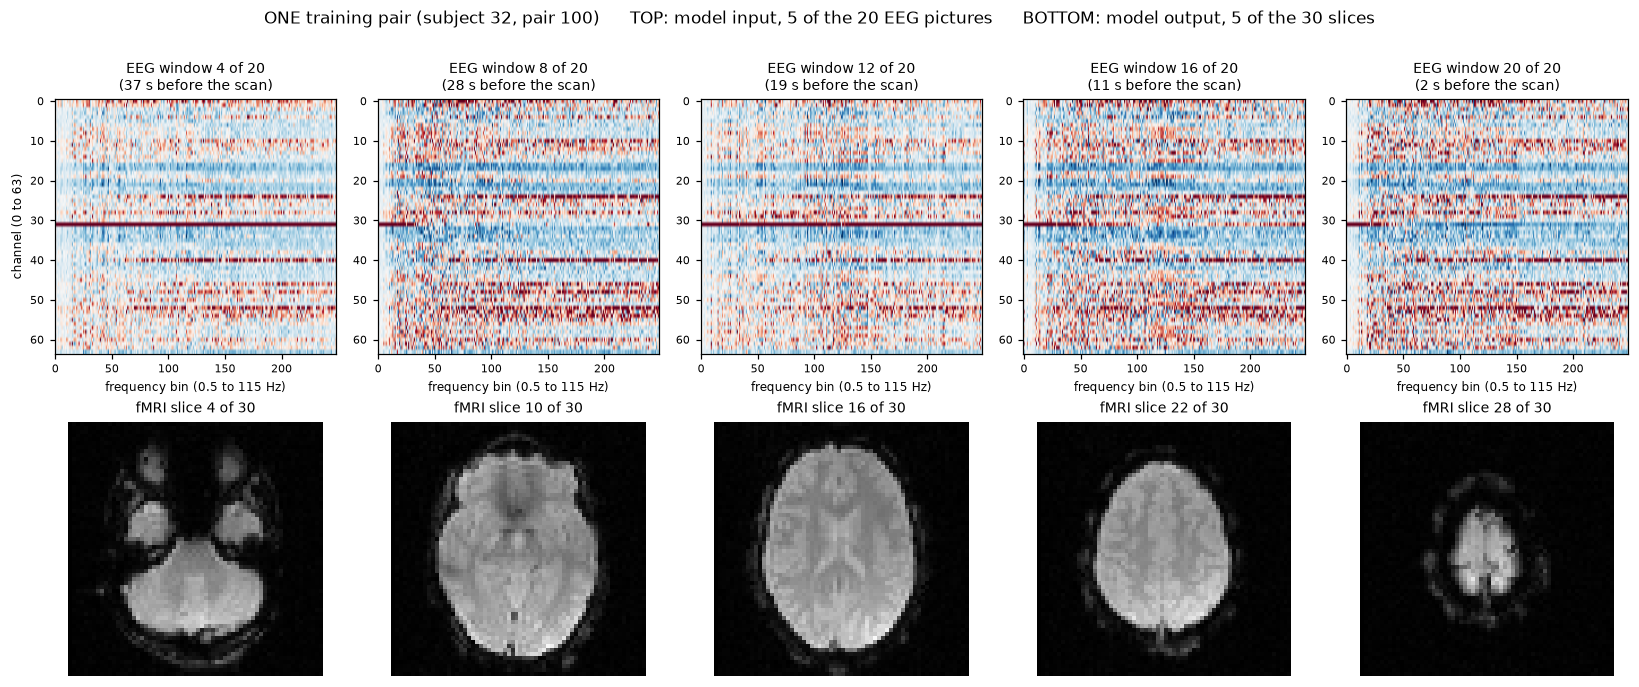

Top row   : red = this channel has MORE of that frequency than the other channels, blue = less.
Bottom row: the brain volume the model must draw from the 20 pictures above.


In [15]:
# One complete training example: the question on top, the answer underneath.
pair = 100

fig, axes = plt.subplots(2, 5, figsize=(15, 6.2))

for j, ax in enumerate(axes[0]):
    step = j * 4 + 3                                   # show windows 3, 7, 11, 15, 19
    # z-scores go negative, so use a blue-white-red map centred on 0.
    ax.imshow(x_demo[pair, step], aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    seconds_before = (INTERVAL_EEG - step) * TR
    ax.set_title(f"EEG window {step+1} of 20\n({seconds_before:.0f} s before the scan)", fontsize=9)
    ax.set_xlabel("frequency bin (0.5 to 115 Hz)", fontsize=8)
    if j == 0: ax.set_ylabel("channel (0 to 63)", fontsize=8)
    ax.tick_params(labelsize=7)

for j, ax in enumerate(axes[1]):
    z = j * 6 + 3                                      # show slices 3, 9, 15, 21, 27
    ax.imshow(np.rot90(y_demo[pair, z]), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"fMRI slice {z+1} of 30", fontsize=9)
    ax.axis("off")

fig.suptitle(f"ONE training pair (subject {demo}, pair {pair})      "
             f"TOP: model input, 5 of the 20 EEG pictures      BOTTOM: model output, 5 of the 30 slices",
             fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

print("Top row   : red = this channel has MORE of that frequency than the other channels, blue = less.")
print("Bottom row: the brain volume the model must draw from the 20 pictures above.")

### What the standardisation does to the numbers

The same EEG values at three stages. This is the picture to keep in mind when someone asks
"what normalisation did you use?".

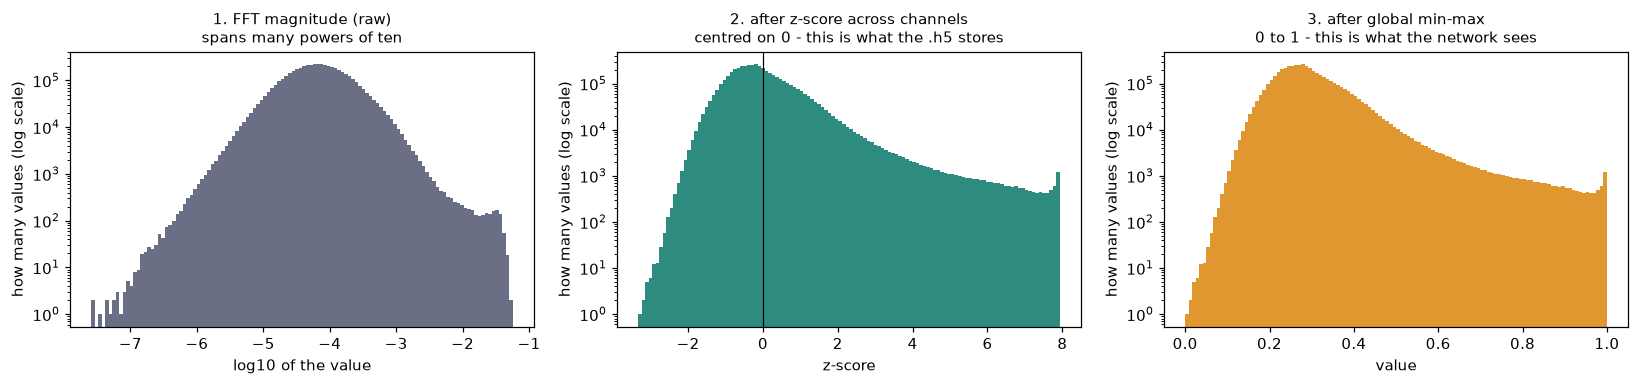

Stage 1 range : 2.57e-08 to 5.72e-02   (volts - tiny, and wildly spread)
Stage 2 range : -3.33 to 7.94
Stage 3 range : 0.00 to 1.00

Note the top of stage 2: 7.936. With 64 channels a z-score can never exceed
sqrt(63) = 7.937. A value that high means ONE channel was far louder than the other 63.
For this subject the loudest channel is most often 'ECG' (index 31), in 47% of all cells.


In [16]:
# Re-do the first half of the EEG pipeline for this subject, just to have the un-standardised values.
raw_demo = mne.io.read_raw_brainvision(eeg_by_subject[demo], preload=True, verbose=0)
v, _ = raw_demo[:, :]
w = int(TR * raw_demo.info["sfreq"])
nw = v.shape[1] // w
magnitude = np.abs(fft(v[:, : nw*w].reshape(v.shape[0], nw, w), axis=-1)[:, :, 1:F_LIMIT])   # (64, n_win, 249)

z_values = zscore(magnitude, axis=0)                                # stage 2: z-score across channels
z_min, z_max = z_values.min(), z_values.max()
unit_values = (z_values - z_min) / (z_max - z_min + 1e-10)          # stage 3: min-max (one subject, for illustration)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

axes[0].hist(np.log10(magnitude.ravel() + 1e-12), bins=120, color="#6B6F85")
axes[0].set_title("1. FFT magnitude (raw)\nspans many powers of ten", fontsize=10)
axes[0].set_xlabel("log10 of the value")

axes[1].hist(z_values.ravel(), bins=120, color="#2E8B80")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("2. after z-score across channels\ncentred on 0 - this is what the .h5 stores", fontsize=10)
axes[1].set_xlabel("z-score")

axes[2].hist(unit_values.ravel(), bins=120, color="#E0972F")
axes[2].set_title("3. after global min-max\n0 to 1 - this is what the network sees", fontsize=10)
axes[2].set_xlabel("value")

for ax in axes:
    ax.set_yscale("log"); ax.set_ylabel("how many values (log scale)")
plt.tight_layout(); plt.show()

print(f"Stage 1 range : {magnitude.min():.2e} to {magnitude.max():.2e}   (volts - tiny, and wildly spread)")
print(f"Stage 2 range : {z_min:.2f} to {z_max:.2f}")
print(f"Stage 3 range : {unit_values.min():.2f} to {unit_values.max():.2f}")
print()
print(f"Note the top of stage 2: {z_max:.3f}. With 64 channels a z-score can never exceed")
print(f"sqrt(63) = {np.sqrt(63):.3f}. A value that high means ONE channel was far louder than the other 63.")
top_channel = np.bincount(z_values.argmax(axis=0).ravel(), minlength=64).argmax()
share = (z_values.argmax(axis=0) == top_channel).mean()
print(f"For this subject the loudest channel is most often '{ch_names[top_channel]}' (index {top_channel}), in {share:.0%} of all cells.")
del raw_demo, v, magnitude, z_values, unit_values

**Why that last line matters.** The z-score compares channels with each other, so one very loud
channel pushes the other 63 down. If the loudest channel is `ECG` - a heartbeat sensor on the
chest, not a brain electrode - then a non-brain signal is setting the scale for the brain
electrodes. We keep it, because the paper keeps all 64 channels and we want comparable numbers.
But it is an honest limitation to mention, and removing it is a natural experiment to try later.

## Step 9 - Process every subject and save the `.h5` files

One file per subject, holding two arrays called `eeg` and `fmri` - the same names and layout the
repo uses, so these files also work with the repo's own scripts.

The cell is safe to re-run: subjects that already have a complete file are skipped.

In [17]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# How much room do we need?  274 x (20*64*249 + 30*64*64) numbers x 4 bytes each.
bytes_per_subject = PAIRS_PER_SUBJECT * (INTERVAL_EEG*64*(F_LIMIT-1) + 30*64*64) * np.dtype(SAVE_DTYPE).itemsize
need_gb = bytes_per_subject * len(SUBJECTS) / 1024**3
free_gb = shutil.disk_usage(OUT_DIR).free / 1024**3
print(f"Output folder : {OUT_DIR}")
print(f"Space needed  : about {need_gb:.1f} GB   ({bytes_per_subject/1024**2:.0f} MB per subject)")
print(f"Space free    : {free_gb:.1f} GB")
assert free_gb > need_gb * 1.05, "Not enough free disk space. Free some room or change OUT_DIR."

Output folder : /media/siddharthk/5646A92F46A91133/EEG_to_FMRI/NODDI_h5
Space needed  : about 7.2 GB   (462 MB per subject)
Space free    : 86.2 GB


In [18]:
def file_is_complete(h5_path):
    """True if the file exists and holds the right shapes (so we can skip it on a re-run)."""
    if not h5_path.exists():
        return False
    try:
        with h5py.File(h5_path, "r") as f:
            return (f["eeg"].shape  == (PAIRS_PER_SUBJECT, INTERVAL_EEG, 64, F_LIMIT - 1) and
                    f["fmri"].shape == (PAIRS_PER_SUBJECT, 30, 64, 64))
    except Exception:
        return False                                   # a half-written file from an interrupted run

t_start = time.time()
for k, subj in enumerate(SUBJECTS, 1):
    out_path = OUT_DIR / f"{subj}.h5"
    if file_is_complete(out_path):
        print(f"[{k:2d}/{len(SUBJECTS)}] subject {subj}: already done, skipping")
        continue

    t0 = time.time()
    fmri_s = load_fmri_stream(fmri_by_subject[subj])           # (294, 64, 64, 30)
    eeg_s, _ = load_eeg_stream(eeg_by_subject[subj])           # (294, 64, 249)
    x, y = make_pairs(eeg_s, fmri_s)                           # (274, 20, 64, 249) and (274, 30, 64, 64)

    assert np.isfinite(x).all() and np.isfinite(y).all(), f"subject {subj}: found NaN or infinity"

    # Write to a temporary name first, then rename. If the run is interrupted mid-write,
    # no broken file is left behind under the real name.
    tmp_path = out_path.with_suffix(".h5.part")
    with h5py.File(tmp_path, "w") as f:
        f.create_dataset("eeg",  data=x)
        f.create_dataset("fmri", data=y)
    tmp_path.replace(out_path)

    print(f"[{k:2d}/{len(SUBJECTS)}] subject {subj}: {len(x)} pairs written  "
          f"({out_path.stat().st_size/1024**2:.0f} MB, {time.time()-t0:.0f} s)")

print(f"\nFinished in {(time.time()-t_start)/60:.1f} minutes.")

[ 1/16] subject 32: 274 pairs written  (462 MB, 1 s)
[ 2/16] subject 35: 274 pairs written  (462 MB, 3 s)
[ 3/16] subject 36: 274 pairs written  (462 MB, 3 s)
[ 4/16] subject 37: 274 pairs written  (462 MB, 3 s)
[ 5/16] subject 38: 274 pairs written  (462 MB, 3 s)
[ 6/16] subject 39: 274 pairs written  (462 MB, 3 s)
[ 7/16] subject 40: 274 pairs written  (462 MB, 4 s)
[ 8/16] subject 42: 274 pairs written  (462 MB, 3 s)
[ 9/16] subject 43: 274 pairs written  (462 MB, 3 s)
[10/16] subject 44: 274 pairs written  (462 MB, 3 s)
[11/16] subject 45: 274 pairs written  (462 MB, 3 s)
[12/16] subject 46: 274 pairs written  (462 MB, 3 s)
[13/16] subject 47: 274 pairs written  (462 MB, 3 s)
[14/16] subject 48: 274 pairs written  (462 MB, 3 s)
[15/16] subject 49: 274 pairs written  (462 MB, 3 s)
[16/16] subject 50: 274 pairs written  (462 MB, 3 s)

Finished in 0.8 minutes.


## Step 10 - Check every file, and record the global EEG range

A last pass over what we wrote: right number of files, right shapes, no broken values, fMRI
exactly 0 to 1.

It also finds the **global EEG minimum and maximum** over all subjects. Those two numbers are
what standardisation step 5 uses in notebook 02 to squeeze the EEG into 0 to 1. Notebook 02
recomputes them itself, so nothing here has to be copied by hand - we save them only so the two
notebooks can be cross-checked.

In [19]:
rows, total = [], 0
g_min, g_max = np.inf, -np.inf

print(f"{'file':<9}{'pairs':>6}  {'eeg shape':<22}{'fmri shape':<20}{'eeg min':>9}{'eeg max':>9}{'fmri range':>14}  status")
print("=" * 100)
for subj in SUBJECTS:
    with h5py.File(OUT_DIR / f"{subj}.h5", "r") as f:
        e, m = f["eeg"][:], f["fmri"][:]
    ok = (e.shape == (PAIRS_PER_SUBJECT, INTERVAL_EEG, 64, F_LIMIT-1) and m.shape == (PAIRS_PER_SUBJECT, 30, 64, 64)
          and np.isfinite(e).all() and np.isfinite(m).all() and m.min() >= 0 and m.max() <= 1)
    total += len(e)
    g_min, g_max = min(g_min, float(e.min())), max(g_max, float(e.max()))
    rows.append(subj)
    print(f"{subj+'.h5':<9}{len(e):>6}  {str(e.shape[1:]):<22}{str(m.shape[1:]):<20}"
          f"{e.min():>9.3f}{e.max():>9.3f}{f'{m.min():.2f} to {m.max():.2f}':>14}  {'ok' if ok else 'PROBLEM'}")
print("=" * 100)
print(f"{len(rows)} files, {total:,} pairs.   Expected {len(SUBJECTS)} files, {len(SUBJECTS)*PAIRS_PER_SUBJECT:,} pairs.")
print()
print(f"Global EEG range over all subjects: {g_min:.4f} to {g_max:.4f}   (ceiling sqrt(63) = {np.sqrt(63):.4f})")

# A small text file describing the dataset. Travels with the .h5 files to the GPU PC.
info = {
    "dataset": "NODDI", "subjects": SUBJECTS, "pairs_per_subject": PAIRS_PER_SUBJECT, "total_pairs": total,
    "eeg_shape_per_pair": [INTERVAL_EEG, 64, F_LIMIT-1], "fmri_shape_per_pair": [30, 64, 64],
    "dtype": np.dtype(SAVE_DTYPE).name, "eeg_global_min": g_min, "eeg_global_max": g_max,
    "settings": {"bold_shift": BOLD_SHIFT, "n_volumes": N_VOLUMES, "interval_eeg": INTERVAL_EEG,
                 "TR_seconds": TR, "fft_bins_kept": F_LIMIT - 1, "eeg_standardisation": "z-score across channels",
                 "fmri_standardisation": "min-max per volume to 0-1"},
}
(OUT_DIR / "dataset_info.json").write_text(json.dumps(info, indent=2))
print(f"Saved summary to {OUT_DIR / 'dataset_info.json'}")

file      pairs  eeg shape             fmri shape            eeg min  eeg max    fmri range  status
32.h5       274  (20, 64, 249)         (30, 64, 64)           -3.335    7.936  0.00 to 1.00  ok
35.h5       274  (20, 64, 249)         (30, 64, 64)           -2.807    7.937  0.00 to 1.00  ok
36.h5       274  (20, 64, 249)         (30, 64, 64)           -2.302    7.934  0.00 to 1.00  ok
37.h5       274  (20, 64, 249)         (30, 64, 64)           -3.032    7.936  0.00 to 1.00  ok
38.h5       274  (20, 64, 249)         (30, 64, 64)           -2.946    7.937  0.00 to 1.00  ok
39.h5       274  (20, 64, 249)         (30, 64, 64)           -2.830    7.932  0.00 to 1.00  ok
40.h5       274  (20, 64, 249)         (30, 64, 64)           -2.749    7.935  0.00 to 1.00  ok
42.h5       274  (20, 64, 249)         (30, 64, 64)           -3.905    7.934  0.00 to 1.00  ok
43.h5       274  (20, 64, 249)         (30, 64, 64)           -2.593    7.934  0.00 to 1.00  ok
44.h5       274  (20, 64, 249)      

## Step 11 - What to take to the GPU PC

Copy these two things:

1. the whole **`NODDI_h5`** folder (16 `.h5` files + `dataset_info.json`, about 7.2 GB)
2. **`02_Train_Spec2VolCAMU_Net.ipynb`**

Put the folder next to the notebook, like this:

```
some_folder/
├── 02_Train_Spec2VolCAMU_Net.ipynb
└── NODDI_h5/
    ├── 32.h5
    ├── 35.h5
    ├── ...
    └── dataset_info.json
```

The raw EEG and fMRI files are **not** needed on the GPU PC.

---

### Summary of this notebook

| stage | shape | meaning |
|---|---|---|
| raw EEG | `(64, ~170000)` | channels x voltage samples at 250 Hz |
| EEG windows | `(64, n, 540)` | cut into 2.16 s pieces |
| EEG spectra | `(64, n, 249)` | FFT magnitude, bins 1-249 |
| EEG stream | `(294, 64, 249)` | z-scored across channels, first 6 dropped |
| raw fMRI | `(64, 64, 30, 300)` | x, y, slice, time |
| fMRI stream | `(294, 64, 64, 30)` | each volume 0-1, first 6 dropped |
| **input `eeg`** | **`(274, 20, 64, 249)`** | pairs, history windows, channels, frequency bins |
| **target `fmri`** | **`(274, 30, 64, 64)`** | pairs, slices, x, y |